# ResNet Ablation Study: ResNet vs PlainNet

## 1. 실험 목적

본 프로젝트의 목적은 ResNet의 핵심 구조인 residual connection, 즉 skip connection이 깊은 CNN 모델의 학습 성능에 어떤 영향을 주는지 확인하는 것이다.

이를 위해 ResNet 모델과 skip connection이 제거된 PlainNet 모델을 동일한 조건에서 학습시키고, validation accuracy와 loss를 비교한다.

본 실험에서는 ResNet-34와 PlainNet-34를 우선 비교하고, 추가적으로 ResNet-50과 PlainNet-50 구조도 구현하여 summary를 확인한다.

Step 2. 라이브러리 import 및 버전 확인

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import time

from torchinfo import summary

print("torch:", torch.__version__)
print("numpy:", np.__version__)

ModuleNotFoundError: No module named 'torchinfo'

In [2]:
!pip install torchinfo

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import time

from torchinfo import summary

print("torch:", torch.__version__)
print("numpy:", np.__version__)

torch: 2.7.1+cu118
numpy: 2.2.6


`torchinfo`는 모델의 layer별 출력 shape와 파라미터 수를 확인하기 위해 사용하는 라이브러리이다.  
현재 실행 환경에 설치되어 있지 않아 `pip install`을 통해 설치하였다.

Step 3. import 셀 다시 실행하기

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import time

from torchinfo import summary

print("torch:", torch.__version__)
print("numpy:", np.__version__)

torch: 2.7.1+cu118
numpy: 2.2.6


Step 4. device 확인하기

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


이 단계의 의미

device는 모델과 데이터를 어디에서 계산할지 정하는 코드야.

cuda → GPU에서 계산
cpu  → CPU에서 계산

ResNet은 모델이 무거운 편이라 GPU를 쓰는 게 훨씬 좋아.

나중에 학습할 때는 모델과 데이터를 모두 같은 device로 보내야 해.

In [6]:
model = model.to(device)
inputs = inputs.to(device)
labels = labels.to(device)

NameError: name 'model' is not defined

BasicBlock 구현하기

In [7]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super(BasicBlock, self).__init__()

        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.use_skip:
            out = out + self.shortcut(identity)

        out = self.relu(out)

        return out

BasicBlock 확인 코드

In [8]:
basic_block = BasicBlock(64, 64, stride=1, use_skip=True)

dummy_input = torch.randn(1, 64, 56, 56)
dummy_output = basic_block(dummy_input)

print(dummy_output.shape)

torch.Size([1, 64, 56, 56])


한 줄 정리

지금 오류는 문제 아냐.
model.to(device)는 나중에 실제 모델을 만든 뒤 학습할 때 쓰는 코드고, 지금은 먼저 BasicBlock부터 구현하면 돼.


BasicBlock  → ResNet-34
Bottleneck  → ResNet-50

Step 6. Bottleneck 구현하기

Bottleneck 구조

입력 x
↓
1×1 Conv
↓
BatchNorm
↓
ReLU
↓
3×3 Conv
↓
BatchNorm
↓
ReLU
↓
1×1 Conv
↓
BatchNorm
↓
입력 x 더하기
↓
ReLU


BasicBlock과 가장 큰 차이는 Conv가 3개라는 점이야.

BasicBlock: 3×3 Conv → 3×3 Conv
Bottleneck: 1×1 Conv → 3×3 Conv → 1×1 Conv

In [9]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super(Bottleneck, self).__init__()

        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            stride=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            out_channels,
            out_channels * self.expansion,
            kernel_size=1,
            stride=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.use_skip:
            out = out + self.shortcut(identity)

        out = self.relu(out)

        return out

Bottleneck 확인 코드

In [10]:
bottleneck_block = Bottleneck(64, 64, stride=1, use_skip=True)

dummy_input = torch.randn(1, 64, 56, 56)
dummy_output = bottleneck_block(dummy_input)

print(dummy_output.shape)

torch.Size([1, 256, 56, 56])


핵심
Bottleneck은 ResNet-50에서 사용하는 블록이며, 1×1 Conv → 3×3 Conv → 1×1 Conv 구조를 가진다. 마지막 1×1 Conv에서 채널 수를 4배로 확장하므로 expansion=4를 사용한다.

Step 7. ResNet 전체 모델 클래스 구현하기

BasicBlock   → ResNet-34용 부품
Bottleneck   → ResNet-50용 부품

입력 이미지
↓
7×7 Conv
↓
BatchNorm
↓
ReLU
↓
MaxPool
↓
Layer1
↓
Layer2
↓
Layer3
↓
Layer4
↓
AdaptiveAvgPool
↓
Linear
↓
최종 클래스 점수

In [11]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000, use_skip=True):
        super(ResNet, self).__init__()

        self.in_channels = 64
        self.use_skip = use_skip

        # 첫 번째 큰 Conv layer
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # 초기 MaxPool
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        # ResNet의 4개 stage
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # 분류기
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []

        # 각 stage의 첫 번째 block
        # stage가 바뀔 때 stride=2가 들어가면서 feature map 크기가 줄어들 수 있음
        layers.append(
            block(
                self.in_channels,
                out_channels,
                stride=stride,
                use_skip=self.use_skip
            )
        )

        self.in_channels = out_channels * block.expansion

        # 나머지 block들은 stride=1로 크기를 유지
        for _ in range(1, num_blocks):
            layers.append(
                block(
                    self.in_channels,
                    out_channels,
                    stride=1,
                    use_skip=self.use_skip
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

이 코드가 하는 일

이 ResNet 클래스는 하나의 모델만 만드는 코드가 아니야.
설정값에 따라 여러 모델을 만들 수 있는 공통 설계도야.

예를 들어:
BasicBlock을 넣으면 ResNet-34 계열
Bottleneck을 넣으면 ResNet-50 계열
use_skip=True면 ResNet
use_skip=False면 PlainNet

이렇게 만들 수 있어.

핵심 인자 설명
def __init__(self, block, layers, num_classes=1000, use_skip=True):
| 인자            | 의미                    |
| ------------- | --------------------- |
| `block`       | 사용할 블록 종류             |
| `layers`      | 각 stage에 블록을 몇 개 쌓을지  |
| `num_classes` | 최종 분류 클래스 수           |
| `use_skip`    | skip connection 사용 여부 |


layers=[3, 4, 6, 3]의 의미
ResNet-34와 ResNet-50은 stage별 블록 반복 수가 같아.

layer1: block 3개
layer2: block 4개
layer3: block 6개
layer4: block 3개

그래서:  layers=[3, 4, 6, 3]  을 사용해.
차이는 블록 종류야.

ResNet-34 → BasicBlock
ResNet-50 → Bottleneck


use_skip의 의미
이 코드에서 아주 중요한 부분이 이거야.
use_skip=True 이면 ResNet이야.

Conv 결과 + 원래 입력

반대로:  use_skip=False  이면 PlainNet이야.

Conv 결과만 사용
즉, 같은 구조에서 skip connection만 켜고 끄는 방식으로 Ablation Study를 할 수 있어.

Step 8. 모델 생성 함수 만들기

이제 ResNet-34, ResNet-50, PlainNet-34, PlainNet-50을 쉽게 만들 수 있도록 함수를 만들자.

In [12]:
def build_resnet34(num_classes=1000):
    return ResNet(
        block=BasicBlock,
        layers=[3, 4, 6, 3],
        num_classes=num_classes,
        use_skip=True
    )


def build_resnet50(num_classes=1000):
    return ResNet(
        block=Bottleneck,
        layers=[3, 4, 6, 3],
        num_classes=num_classes,
        use_skip=True
    )


def build_plainnet34(num_classes=1000):
    return ResNet(
        block=BasicBlock,
        layers=[3, 4, 6, 3],
        num_classes=num_classes,
        use_skip=False
    )


def build_plainnet50(num_classes=1000):
    return ResNet(
        block=Bottleneck,
        layers=[3, 4, 6, 3],
        num_classes=num_classes,
        use_skip=False
    )

이 함수들이 만드는 모델
| 함수                   | 모델          | 블록         | skip connection |
| -------------------- | ----------- | ---------- | --------------- |
| `build_resnet34()`   | ResNet-34   | BasicBlock | 사용              |
| `build_plainnet34()` | PlainNet-34 | BasicBlock | 미사용             |
| `build_resnet50()`   | ResNet-50   | Bottleneck | 사용              |
| `build_plainnet50()` | PlainNet-50 | Bottleneck | 미사용             |



여기까지 끝나면 확인할 것
이번 단계에서는 아직 summary까지 보지 않아.
먼저 코드가 에러 없이 실행되는지만 확인하면 돼.

ResNet 클래스 정의 완료
build 함수 4개 정의 완료

 ResNet-34 summary 확인

In [13]:
resnet_34 = build_resnet34()
summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─Sequential: 3-6              [1, 64, 56, 56]           --
│

핵심

ResNet-34 최종 출력: [1, 1000]
총 파라미터 수: 21,797,672
사용 블록: BasicBlock
stage 반복 수: [3, 4, 6, 3]


ResNet-34는 입력 이미지 [1, 3, 224, 224]를 받아서 최종적으로 [1, 1000]을 출력


입력 [1, 3, 224, 224]
↓
Conv1 → [1, 64, 112, 112]
↓
MaxPool → [1, 64, 56, 56]
↓
layer1 → [1, 64, 56, 56]
↓
layer2 → [1, 128, 28, 28]
↓
layer3 → [1, 256, 14, 14]
↓
layer4 → [1, 512, 7, 7]
↓
AdaptiveAvgPool → [1, 512, 1, 1]
↓
Linear → [1, 1000]


summary 안에 BasicBlock이 반복해서 나온 것도 중요해.
ResNet-34는 BasicBlock을 사용하는 모델이니까 정상 구조

### ResNet-34 모델 summary 확인

`build_resnet34()` 함수를 이용하여 ResNet-34 모델을 생성하고, `torchinfo.summary()`를 통해 모델 구조를 확인하였다.  
입력 크기는 ImageNet 구조에 맞춰 `[1, 3, 224, 224]`로 설정하였다.

summary 결과, ResNet-34는 초기 `7×7 Conv`, BatchNorm, ReLU, MaxPool을 거친 뒤 4개의 residual stage를 통과한다.  
각 stage는 BasicBlock을 `[3, 4, 6, 3]`개씩 반복하여 구성되며, feature map의 공간 크기는 `56×56 → 28×28 → 14×14 → 7×7`로 감소하고, 채널 수는 `64 → 128 → 256 → 512`로 증가하였다.

최종적으로 `AdaptiveAvgPool2d`를 통해 feature map이 `[1, 512, 1, 1]`로 압축되고, 마지막 Linear layer를 거쳐 `[1, 1000]` 형태의 출력을 생성하였다.  
총 학습 가능한 파라미터 수는 21,797,672개로 확인되었다.

ResNet-50 summary 확인

In [14]:
resnet_50 = build_resnet50()
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

### ResNet-50 모델 summary 확인

`build_resnet50()` 함수를 이용하여 ResNet-50 모델을 생성하고, `torchinfo.summary()`를 통해 모델 구조를 확인하였다.  
입력 크기는 ImageNet 구조에 맞춰 `[1, 3, 224, 224]`로 설정하였다.

summary 결과, ResNet-50은 초기 `7×7 Conv`, BatchNorm, ReLU, MaxPool을 거친 뒤 4개의 residual stage를 통과한다.  
각 stage는 Bottleneck block을 `[3, 4, 6, 3]`개씩 반복하여 구성되며, feature map의 공간 크기는 `56×56 → 28×28 → 14×14 → 7×7`로 감소하고, 채널 수는 `256 → 512 → 1024 → 2048`로 증가하였다.

최종적으로 `AdaptiveAvgPool2d`를 통해 feature map이 `[1, 2048, 1, 1]`로 압축되고, 마지막 Linear layer를 거쳐 `[1, 1000]` 형태의 출력을 생성하였다.  
총 학습 가능한 파라미터 수는 25,557,032개로 확인되었다.

ResNet-34는 BasicBlock을 사용하고, ResNet-50은 Bottleneck block을 사용한다.  
두 모델 모두 stage별 block 반복 수는 `[3, 4, 6, 3]`으로 동일하지만, ResNet-50은 block 내부에 `1×1 Conv → 3×3 Conv → 1×1 Conv` 구조를 사용하기 때문에 더 깊은 모델 구조를 가진다.

PlainNet-34 summary 확인
이제 루브릭을 만족하려면 skip connection이 없는 모델, 즉 PlainNet도 확인해야 해.

PlainNet-34에서 확인할 것
PlainNet-34는 ResNet-34와 거의 같은 구조여야 해.
다만 차이는 이것 하나야.
ResNet-34: skip connection 사용
PlainNet-34: skip connection 미사용

In [15]:
plainnet_34 = build_plainnet34()
summary(plainnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

현재까지 다시 복구한 상태는 아주 좋아.

ResNet-34 summary 확인 완료
ResNet-50 summary 확인 완료
PlainNet-34 summary 확인 완료

PlainNet-34 결과가 의미하는 것
PlainNet-34는 ResNet-34와 거의 같은 구조로
BasicBlock 반복 수: [3, 4, 6, 3]
최종 출력: [1, 1000]
총 파라미터 수: 21,797,672

다만 차이는 하나야.

ResNet-34   → skip connection 사용
PlainNet-34 → skip connection 미사용

### PlainNet-34 모델 summary 확인

`build_plainnet34()` 함수를 이용하여 PlainNet-34 모델을 생성하고, `torchinfo.summary()`를 통해 모델 구조를 확인하였다.  
PlainNet-34는 ResNet-34와 동일하게 BasicBlock을 `[3, 4, 6, 3]`개씩 쌓은 구조를 가진다.

입력 크기는 `[1, 3, 224, 224]`로 설정하였으며, 각 stage를 지나면서 feature map의 공간 크기는 `56×56 → 28×28 → 14×14 → 7×7`로 감소하고, 채널 수는 `64 → 128 → 256 → 512`로 증가하였다.

ResNet-34와 PlainNet-34의 차이는 skip connection의 사용 여부이다.  
ResNet-34는 block의 출력에 원래 입력을 더하는 residual connection을 사용하지만, PlainNet-34는 해당 연결을 사용하지 않고 convolution 결과만 다음 layer로 전달한다.  
따라서 두 모델을 비교하면 residual connection이 깊은 네트워크 학습에 미치는 영향을 확인할 수 있다.

PlainNet-50 summary 확인

In [16]:
plainnet_50 = build_plainnet50()
summary(plainnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [1, 256, 56, 56]          16,896
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           -

1. ResNet-34     → BasicBlock, skip connection 사용
2. ResNet-50     → Bottleneck, skip connection 사용
3. PlainNet-34   → BasicBlock, skip connection 미사용
4. PlainNet-50   → Bottleneck, skip connection 미사용

PlainNet-50 결과에서 확인된 것

PlainNet-50은 Bottleneck block을 사용하고 있어.

Bottleneck
Bottleneck
Bottleneck
...


stage별 출력 shape도 정상적

| 단계      | 출력 shape            |
| ------- | ------------------- |
| layer1  | `[1, 256, 56, 56]`  |
| layer2  | `[1, 512, 28, 28]`  |
| layer3  | `[1, 1024, 14, 14]` |
| layer4  | `[1, 2048, 7, 7]`   |
| AvgPool | `[1, 2048, 1, 1]`   |
| 최종 출력   | `[1, 1000]`         |


총 파라미터 수는:

25,557,032

PlainNet-50도 summary 맨 위에는 ResNet이라고 나오지만, 이건 우리가 같은 ResNet 클래스를 재사용했기 때문이야. 실제로는 build_plainnet50()에서 use_skip=False로 만들었기 때문에 skip connection 없이 동작하는 PlainNet-50이 맞아.

### PlainNet-50 모델 summary 확인

`build_plainnet50()` 함수를 이용하여 PlainNet-50 모델을 생성하고, `torchinfo.summary()`를 통해 모델 구조를 확인하였다.  
PlainNet-50은 ResNet-50과 동일하게 Bottleneck block을 `[3, 4, 6, 3]`개씩 쌓은 구조를 가진다.

입력 크기는 `[1, 3, 224, 224]`로 설정하였으며, 각 stage를 지나면서 feature map의 공간 크기는 `56×56 → 28×28 → 14×14 → 7×7`로 감소하고, 채널 수는 `256 → 512 → 1024 → 2048`로 증가하였다.

ResNet-50과 PlainNet-50의 차이는 skip connection의 사용 여부이다.  
ResNet-50은 Bottleneck block의 출력에 원래 입력을 더하는 residual connection을 사용하지만, PlainNet-50은 해당 연결을 사용하지 않고 convolution 결과만 다음 layer로 전달한다.

따라서 ResNet-50과 PlainNet-50을 비교하면 깊은 네트워크에서 residual connection이 학습 성능에 어떤 영향을 주는지 확인할 수 있다.

### ResNet / PlainNet 모델 구조 확인 요약

| 모델 | 사용 블록 | Stage 반복 수 | Skip connection | 최종 출력 | 총 파라미터 수 |
|---|---|---|---|---|---:|
| ResNet-34 | BasicBlock | `[3, 4, 6, 3]` | 사용 | `[1, 1000]` | 21,797,672 |
| PlainNet-34 | BasicBlock | `[3, 4, 6, 3]` | 미사용 | `[1, 1000]` | 21,797,672 |
| ResNet-50 | Bottleneck | `[3, 4, 6, 3]` | 사용 | `[1, 1000]` | 25,557,032 |
| PlainNet-50 | Bottleneck | `[3, 4, 6, 3]` | 미사용 | `[1, 1000]` | 25,557,032 |

네 모델 모두 동일한 입력 크기 `[1, 3, 224, 224]`에 대해 정상적으로 forward가 가능하며, 최종 출력은 `[1, 1000]`으로 확인되었다.  
ResNet 계열과 PlainNet 계열은 동일한 block 반복 구조를 가지지만, ResNet은 residual connection을 사용하고 PlainNet은 이를 사용하지 않는다는 점에서 차이가 있다.  
따라서 이후 학습 실험에서는 skip connection의 유무가 validation accuracy와 loss에 어떤 영향을 주는지 비교한다.

## 5. ResNet vs PlainNet 학습 및 Ablation Study

앞 단계에서 ResNet-34, ResNet-50, PlainNet-34, PlainNet-50 모델 구조를 확인하였다.  
이제 동일한 데이터셋과 동일한 epoch 조건에서 모델을 학습시켜 residual connection의 효과를 비교한다.

본 실험에서는 CIFAR-10 데이터셋을 사용하되, ResNet 구조의 입력 크기에 맞추기 위해 이미지를 `224×224`로 resize하였다.  
실험 시간을 줄이기 위해 학습 데이터 일부와 테스트 데이터 일부를 사용하여 비교 실험을 진행한다.

In [18]:
BATCH_SIZE = 32
EPOCH = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [19]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

full_testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

train_subset = Subset(full_trainset, range(5000))
test_subset = Subset(full_testset, range(1000))

trainloader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

testloader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(trainloader))

print(images.shape)
print(labels.shape)

100%|██████████| 170M/170M [00:12<00:00, 13.9MB/s] 


torch.Size([32, 3, 224, 224])
torch.Size([32])


Step 9. 학습 함수 train_model() 만들기

1. train loss
2. validation loss / validation accuracy

In [20]:
def train_model(model, trainloader, testloader, criterion, optimizer, device, epochs=2):
    model = model.to(device)

    train_losses = []
    val_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        # -------------------------
        # 1. Training phase
        # -------------------------
        model.train()
        running_loss = 0.0

        for inputs, labels in trainloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(trainloader)
        train_losses.append(train_loss)

        # -------------------------
        # 2. Validation phase
        # -------------------------
        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(testloader)
        val_acc = 100 * correct / total

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

    elapsed_time = time.time() - start_time

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "val_acc": val_accuracies,
        "time": elapsed_time
    }

    return history

이 함수가 하는 일

이 함수는 모델 하나를 받아서 학습하고, 결과를 기록해주는 함수야.
예를 들어 나중에 이렇게 쓸 수 있어.
history_resnet34 = train_model(
    model=resnet34_train,
    trainloader=trainloader,
    testloader=testloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCH
)

그러면 history_resnet34 안에 이런 값들이 저장돼.
train_loss
val_loss
val_acc
time

즉, 나중에 그래프와 결과표를 만들 수 있어.

코드 핵심 설명

1. 학습 모드
model.train()


이건 모델을 학습 모드로 바꾸는 코드야.
BatchNorm, Dropout 같은 layer는 학습할 때와 평가할 때 동작이 조금 달라.
그래서 학습할 때는 반드시 model.train()을 해줘야 해.

3. 기울기 초기화
optimizer.zero_grad()
PyTorch는 gradient를 자동으로 누적해.
그래서 매 batch마다 이전 gradient를 지워줘야 해.

3. 예측
outputs = model(inputs)
모델에 이미지를 넣어서 예측값을 얻는 과정이야.

5. 손실 계산
loss = criterion(outputs, labels)
모델 예측과 실제 정답을 비교해서 loss를 계산해.

7. 역전파
loss.backward()
loss를 줄이기 위해 각 파라미터가 어느 방향으로 바뀌어야 하는지 계산해.

6. 가중치 업데이트
optimizer.step()
계산된 gradient를 이용해서 모델의 가중치를 실제로 업데이트해.

7. 평가 모드
model.eval()
검증 단계에서는 모델을 평가 모드로 바꿔.
그리고 gradient 계산도 꺼.

with torch.no_grad():
검증할 때는 학습이 아니라 성능 확인만 하기 때문에 gradient가 필요 없어.
그래서 메모리를 아끼고 속도도 조금 빨라져.

Step 10. 먼저 ResNet-34와 PlainNet-34 학습하기

### 5-1. ResNet-34와 PlainNet-34 학습 비교

먼저 BasicBlock을 사용하는 ResNet-34와 PlainNet-34를 동일한 epoch, 동일한 데이터셋 조건에서 학습한다.  
두 모델의 차이는 residual connection의 사용 여부이며, 이를 통해 skip connection이 학습 성능에 미치는 영향을 비교한다.

In [ ]:
criterion = nn.CrossEntropyLoss()

In [35]:
resnet34_train = build_resnet34(num_classes=10)

optimizer_resnet34 = optim.SGD(
    resnet34_train.parameters(),
    lr=0.001,
    momentum=0.9,
    weight_decay=1e-4
)

history_resnet34 = train_model(
    model=resnet34_train,
    trainloader=trainloader,
    testloader=testloader,
    criterion=criterion,
    optimizer=optimizer_resnet34,
    device=device,
    epochs=EPOCH
)

Epoch [1/2] Train Loss: 1.9213 | Val Loss: 2.0564 | Val Acc: 32.10%
Epoch [2/2] Train Loss: 1.5931 | Val Loss: 2.0490 | Val Acc: 34.20%


| 모델        | Epoch | Train Loss | Val Loss | Val Acc |
| --------- | ----: | ---------: | -------: | ------: |
| ResNet-34 |     1 |     1.9213 |   2.0564 |  32.10% |
| ResNet-34 |     2 |     1.5931 |   2.0490 |  34.20% |


PlainNet-34 학습

In [36]:
plainnet34_train = build_plainnet34(num_classes=10)

optimizer_plainnet34 = optim.SGD(
    plainnet34_train.parameters(),
    lr=0.001,
    momentum=0.9,
    weight_decay=1e-4
)

history_plainnet34 = train_model(
    model=plainnet34_train,
    trainloader=trainloader,
    testloader=testloader,
    criterion=criterion,
    optimizer=optimizer_plainnet34,
    device=device,
    epochs=EPOCH
)

Epoch [1/2] Train Loss: 2.1978 | Val Loss: 2.0437 | Val Acc: 25.40%
Epoch [2/2] Train Loss: 1.9268 | Val Loss: 1.8709 | Val Acc: 29.30%


| 모델          | Epoch | Train Loss | Val Loss | Val Acc |
| ----------- | ----: | ---------: | -------: | ------: |
| PlainNet-34 |     1 |     2.1978 |   2.0437 |  25.40% |
| PlainNet-34 |     2 |     1.9268 |   1.8709 |  29.30% |


### ResNet-34 vs PlainNet-34 Ablation Study 결과

| 모델 | Skip Connection | Epoch 1 Train Loss | Epoch 2 Train Loss | Epoch 1 Val Loss | Epoch 2 Val Loss | Epoch 1 Val Acc | Epoch 2 Val Acc |
|---|---|---:|---:|---:|---:|---:|---:|
| ResNet-34 | 사용 | 1.9213 | 1.5931 | 2.0564 | 2.0490 | 32.10% | 34.20% |
| PlainNet-34 | 미사용 | 2.1978 | 1.9268 | 2.0437 | 1.8709 | 25.40% | 29.30% |

ResNet-34와 PlainNet-34를 동일한 CIFAR-10 부분 데이터셋, 동일한 epoch 조건에서 학습하였다.  
두 모델 모두 학습이 진행되면서 train loss가 감소하였으며, validation accuracy도 증가하였다.

ResNet-34의 train loss는 `1.9213 → 1.5931`로 감소하였고, validation accuracy는 `32.10% → 34.20%`로 증가하였다.  
PlainNet-34의 train loss는 `2.1978 → 1.9268`로 감소하였고, validation accuracy는 `25.40% → 29.30%`로 증가하였다.

최종 epoch 기준으로 ResNet-34의 validation accuracy는 `34.20%`, PlainNet-34의 validation accuracy는 `29.30%`로 나타났다.  
따라서 동일한 BasicBlock 반복 구조에서 skip connection을 사용하는 ResNet-34가 skip connection을 제거한 PlainNet-34보다 더 높은 검증 정확도를 보였다.

이 결과는 residual connection이 깊은 네트워크의 학습 안정성과 성능 향상에 긍정적인 영향을 줄 수 있음을 보여준다.

In [ ]:
그래프 코드

In [38]:
resnet34_train_loss = [1.9213, 1.5931]
plainnet34_train_loss = [2.1978, 1.9268]

resnet34_val_loss = [2.0564, 2.0490]
plainnet34_val_loss = [2.0437, 1.8709]

resnet34_val_acc = [32.10, 34.20]
plainnet34_val_acc = [25.40, 29.30]

epochs = [1, 2]

train loss 그래프

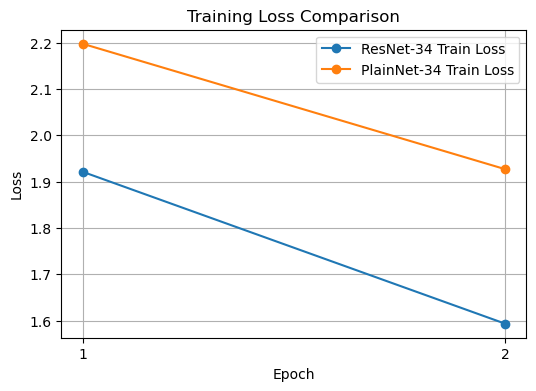

In [40]:
plt.figure(figsize=(6, 4))
plt.plot(epochs, resnet34_train_loss, marker='o', label='ResNet-34 Train Loss')
plt.plot(epochs, plainnet34_train_loss, marker='o', label='PlainNet-34 Train Loss')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

validation accuracy 그래프

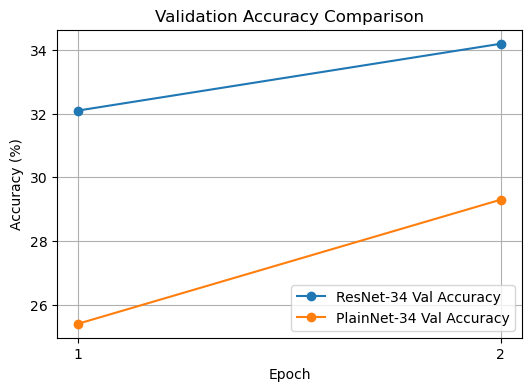

In [42]:
plt.figure(figsize=(6, 4))
plt.plot(epochs, resnet34_val_acc, marker='o', label='ResNet-34 Val Accuracy')
plt.plot(epochs, plainnet34_val_acc, marker='o', label='PlainNet-34 Val Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

| 루브릭                                       | 현재 상태                        |
| ----------------------------------------- | ---------------------------- |
| ResNet-34/50 구현 및 summary 확인              | 완료                           |
| PlainNet-34/50 구현 및 summary 확인            | 완료                           |
| loss 감소 확인                                | ResNet-34, PlainNet-34 모두 확인 |
| validation accuracy 기준 Ablation Study 결과표 | ResNet-34 vs PlainNet-34 완료  |


## 6. 결론

본 실험에서는 ResNet의 핵심 요소인 residual connection의 효과를 확인하기 위해 ResNet-34와 PlainNet-34를 비교하였다.  
두 모델은 동일한 BasicBlock 반복 구조를 가지지만, ResNet-34는 skip connection을 사용하고 PlainNet-34는 이를 사용하지 않는다는 차이가 있다.

실험 결과, 두 모델 모두 epoch이 진행됨에 따라 train loss가 감소하여 학습이 정상적으로 이루어졌음을 확인하였다.  
최종 epoch 기준 validation accuracy는 ResNet-34가 `34.20%`, PlainNet-34가 `29.30%`로 나타났으며, ResNet-34가 더 높은 성능을 보였다.

따라서 본 Ablation Study를 통해 residual connection이 깊은 CNN 모델의 학습 안정성과 검증 성능 향상에 기여할 수 있음을 확인하였다.  
다만 본 실험은 시간과 자원 제약으로 CIFAR-10 부분 데이터셋과 2 epoch만 사용했기 때문에, 더 정확한 비교를 위해서는 전체 데이터셋과 더 많은 epoch에서 추가 실험이 필요하다.

1. 결과값 리스트로 정리하기

In [43]:
resnet34_train_loss = [1.9213, 1.5931]
plainnet34_train_loss = [2.1978, 1.9268]

resnet34_val_loss = [2.0564, 2.0490]
plainnet34_val_loss = [2.0437, 1.8709]

resnet34_val_acc = [32.10, 34.20]
plainnet34_val_acc = [25.40, 29.30]

epochs = [1, 2]

2. Train Loss 그래프 그리기

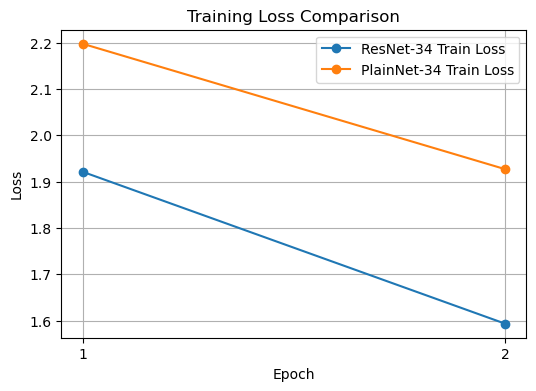

In [44]:
plt.figure(figsize=(6, 4))

plt.plot(epochs, resnet34_train_loss, marker='o', label='ResNet-34 Train Loss')
plt.plot(epochs, plainnet34_train_loss, marker='o', label='PlainNet-34 Train Loss')

plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

ResNet-34와 PlainNet-34 모두 epoch이 진행되면서 train loss가 감소했는가?

ResNet-34: 1.9213 → 1.5931
PlainNet-34: 2.1978 → 1.9268

3. Validation Accuracy 그래프 그리기

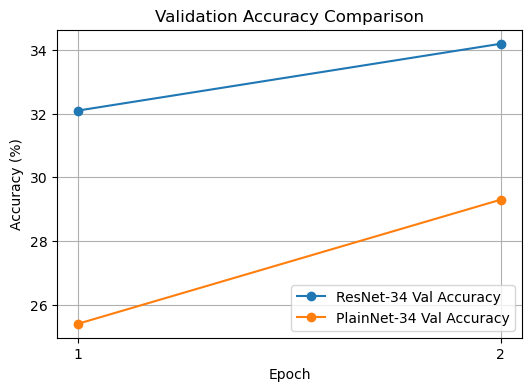

In [45]:
plt.figure(figsize=(6, 4))

plt.plot(epochs, resnet34_val_acc, marker='o', label='ResNet-34 Val Accuracy')
plt.plot(epochs, plainnet34_val_acc, marker='o', label='PlainNet-34 Val Accuracy')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

ResNet-34가 PlainNet-34보다 validation accuracy가 높은가?

ResNet-34: 34.20%
PlainNet-34: 29.30%

그래서 ResNet-34가 더 높게 나온 걸 확인할 수 있었다.

4. 최종 결과표 넣기

### ResNet-34 vs PlainNet-34 Ablation Study 결과

| 모델 | Skip Connection | Epoch 1 Train Loss | Epoch 2 Train Loss | Epoch 1 Val Loss | Epoch 2 Val Loss | Epoch 1 Val Acc | Epoch 2 Val Acc |
|---|---|---:|---:|---:|---:|---:|---:|
| ResNet-34 | 사용 | 1.9213 | 1.5931 | 2.0564 | 2.0490 | 32.10% | 34.20% |
| PlainNet-34 | 미사용 | 2.1978 | 1.9268 | 2.0437 | 1.8709 | 25.40% | 29.30% |

5. 결과 해석 넣기

### 결과 해석

ResNet-34와 PlainNet-34를 동일한 CIFAR-10 부분 데이터셋, 동일한 epoch 조건에서 학습하였다.  
두 모델 모두 학습이 진행되면서 train loss가 감소하였으며, validation accuracy도 증가하였다.

ResNet-34의 train loss는 `1.9213 → 1.5931`로 감소하였고, validation accuracy는 `32.10% → 34.20%`로 증가하였다.  
PlainNet-34의 train loss는 `2.1978 → 1.9268`로 감소하였고, validation accuracy는 `25.40% → 29.30%`로 증가하였다.

최종 epoch 기준으로 ResNet-34의 validation accuracy는 `34.20%`, PlainNet-34의 validation accuracy는 `29.30%`로 나타났다.  
따라서 동일한 BasicBlock 반복 구조에서 skip connection을 사용하는 ResNet-34가 skip connection을 제거한 PlainNet-34보다 더 높은 검증 정확도를 보였다.

이 결과는 residual connection이 깊은 네트워크의 학습 안정성과 성능 향상에 긍정적인 영향을 줄 수 있음을 보여준다.

6. 결론 넣기

## 6. 결론

본 실험에서는 ResNet의 핵심 요소인 residual connection의 효과를 확인하기 위해 ResNet-34와 PlainNet-34를 비교하였다.  
두 모델은 동일한 BasicBlock 반복 구조를 가지지만, ResNet-34는 skip connection을 사용하고 PlainNet-34는 이를 사용하지 않는다는 차이가 있다.

실험 결과, 두 모델 모두 epoch이 진행됨에 따라 train loss가 감소하여 학습이 정상적으로 이루어졌음을 확인하였다.  
최종 epoch 기준 validation accuracy는 ResNet-34가 `34.20%`, PlainNet-34가 `29.30%`로 나타났으며, ResNet-34가 더 높은 성능을 보였다.

따라서 본 Ablation Study를 통해 residual connection이 깊은 CNN 모델의 학습 안정성과 검증 성능 향상에 기여할 수 있음을 확인하였다.  
다만 본 실험은 시간과 자원 제약으로 CIFAR-10 부분 데이터셋과 2 epoch만 사용했기 때문에, 더 정확한 비교를 위해서는 전체 데이터셋과 더 많은 epoch에서 추가 실험이 필요하다.